Epoch [1/50], Loss: 0.0403
Epoch [2/50], Loss: 0.0300
Epoch [3/50], Loss: 0.0283
Epoch [4/50], Loss: 0.0274
Epoch [5/50], Loss: 0.0283
Epoch [6/50], Loss: 0.0271
Epoch [7/50], Loss: 0.0273
Epoch [8/50], Loss: 0.0281
Epoch [9/50], Loss: 0.0273
Epoch [10/50], Loss: 0.0286
Epoch [11/50], Loss: 0.0285
Epoch [12/50], Loss: 0.0259
Epoch [13/50], Loss: 0.0288
Epoch [14/50], Loss: 0.0270
Epoch [15/50], Loss: 0.0252
Epoch [16/50], Loss: 0.0260
Epoch [17/50], Loss: 0.0265
Epoch [18/50], Loss: 0.0248
Epoch [19/50], Loss: 0.0237
Epoch [20/50], Loss: 0.0249
Epoch [21/50], Loss: 0.0269
Epoch [22/50], Loss: 0.0253
Epoch [23/50], Loss: 0.0236
Epoch [24/50], Loss: 0.0221
Epoch [25/50], Loss: 0.0251
Epoch [26/50], Loss: 0.0256
Epoch [27/50], Loss: 0.0221
Epoch [28/50], Loss: 0.0239
Epoch [29/50], Loss: 0.0248
Epoch [30/50], Loss: 0.0247
Epoch [31/50], Loss: 0.0239
Epoch [32/50], Loss: 0.0227
Epoch [33/50], Loss: 0.0239
Epoch [34/50], Loss: 0.0250
Epoch [35/50], Loss: 0.0244
Epoch [36/50], Loss: 0.0228
E

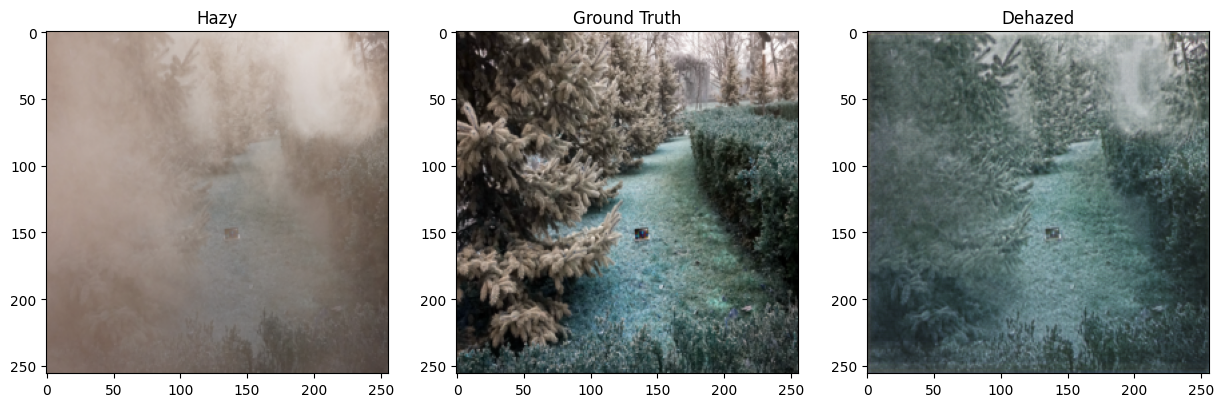

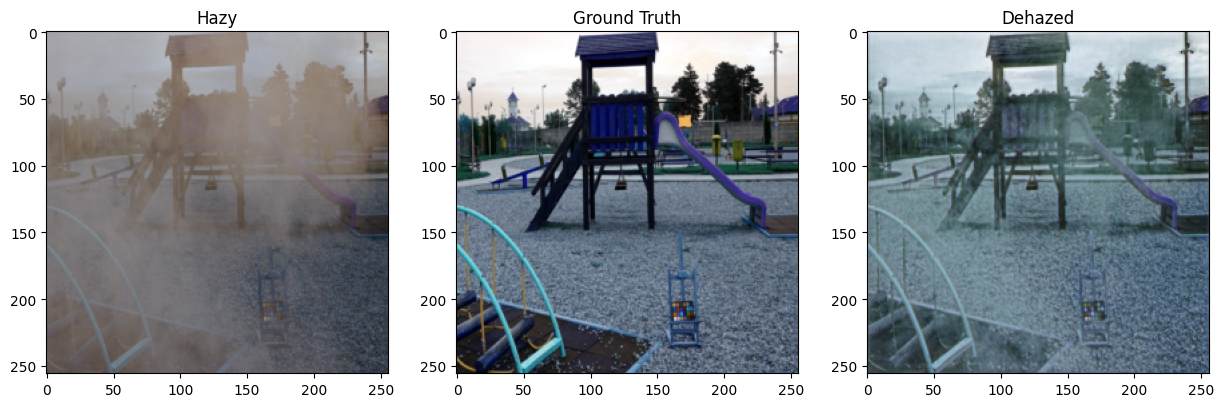

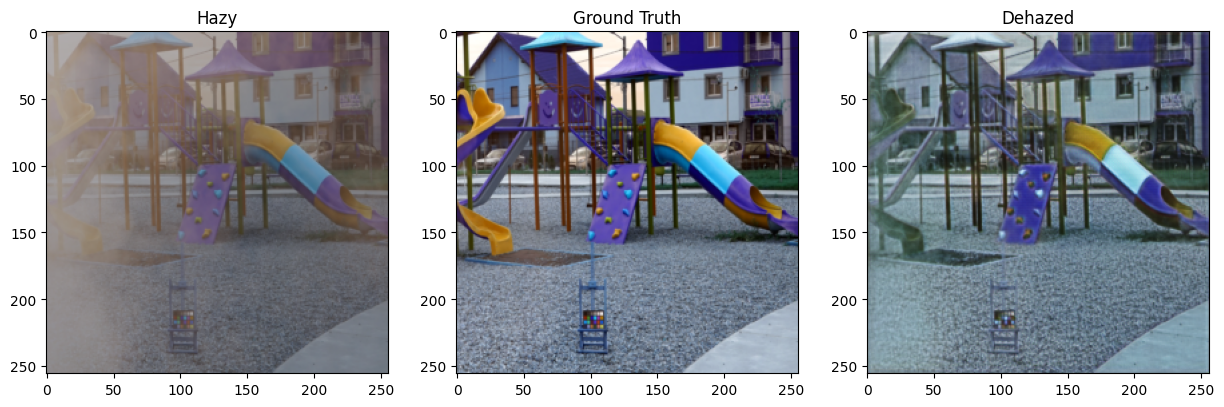

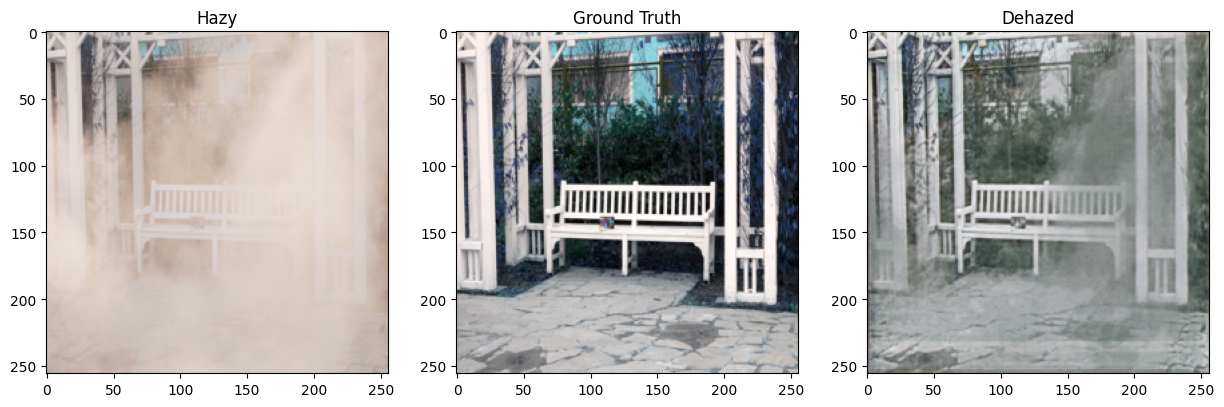

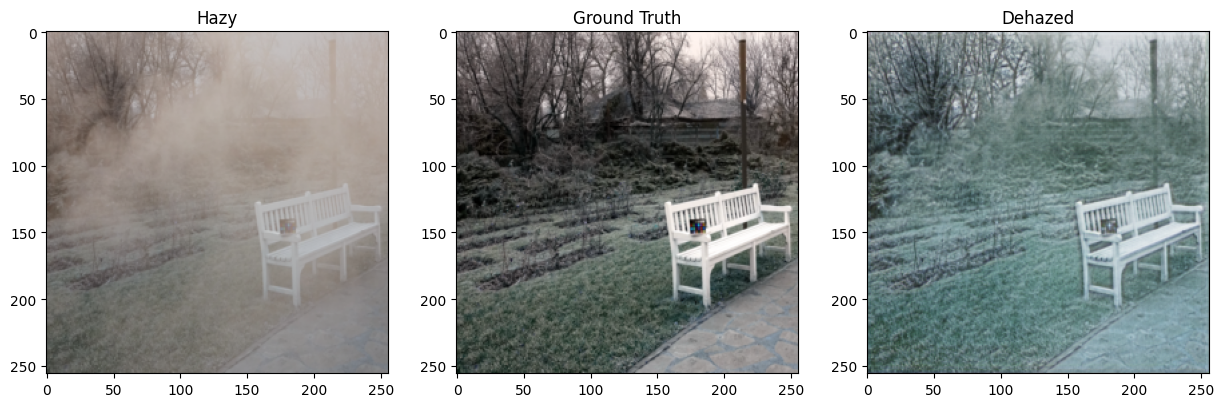

In [1]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

# Dataset class
class HazyDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_pairs = self._get_image_pairs()

    def _get_image_pairs(self):
        images = sorted([f for f in os.listdir(self.image_dir) if f.endswith('.png')])
        hazy_images = [img for img in images if img.endswith('_hazy.png')]
        gt_images = [img for img in images if img.endswith('_GT.png')]
        image_pairs = []
        for hazy_img in hazy_images:
            base_name = hazy_img.split('_hazy')[0]
            gt_img = base_name + '_GT.png'
            if gt_img in gt_images:
                image_pairs.append((hazy_img, gt_img))
        return image_pairs

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        hazy_img, gt_img = self.image_pairs[idx]
        hazy_path = os.path.join(self.image_dir, hazy_img)
        gt_path = os.path.join(self.image_dir, gt_img)

        hazy = cv2.imread(hazy_path)
        gt = cv2.imread(gt_path)

        if self.transform:
            hazy = self.transform(hazy)
            gt = self.transform(gt)

        return hazy, gt

# Transformation pipeline
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# U-Net model definition
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def CBR(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        self.enc1 = CBR(3, 64)
        self.enc2 = CBR(64, 128)
        self.enc3 = CBR(128, 256)
        self.enc4 = CBR(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.upconv4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = CBR(512, 256)
        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = CBR(256, 128)
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = CBR(128, 64)
        self.dec1 = nn.Conv2d(64, 3, kernel_size=3, padding=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        dec4 = self.upconv4(enc4)
        dec4 = self.dec4(torch.cat([dec4, enc3], dim=1))
        dec3 = self.upconv3(dec4)
        dec3 = self.dec3(torch.cat([dec3, enc2], dim=1))
        dec2 = self.upconv2(dec3)
        dec2 = self.dec2(torch.cat([dec2, enc1], dim=1))
        dec1 = self.dec1(dec2)
        return torch.sigmoid(dec1)

# Training configuration
image_dir = '/content/drive/MyDrive/Colab Notebooks/desmoking algo/NH-HAZE'  # Directory containing all images
batch_size = 4
learning_rate = 0.001
num_epochs = 50

# Dataset and DataLoader
dataset = HazyDataset(image_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model, Loss, Optimizer
model = UNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for hazy, gt in dataloader:
        optimizer.zero_grad()
        outputs = model(hazy)
        loss = criterion(outputs, gt)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * hazy.size(0)

    epoch_loss = running_loss / len(dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

# Save the model
torch.save(model.state_dict(), 'unet_dehazing_model.pth')

# Evaluation
model.eval()
num_images_to_show = 5  # Set the number of images to show
images_shown = 0

with torch.no_grad():
    for hazy, gt in dataloader:
        outputs = model(hazy)
        for i in range(len(hazy)):
            if images_shown >= num_images_to_show:
                break

            hazy_img = hazy[i].permute(1, 2, 0).numpy()
            gt_img = gt[i].permute(1, 2, 0).numpy()
            output_img = outputs[i].permute(1, 2, 0).numpy()

            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            axs[0].imshow(hazy_img)
            axs[0].set_title('Hazy')
            axs[1].imshow(gt_img)
            axs[1].set_title('Ground Truth')
            axs[2].imshow(output_img)
            axs[2].set_title('Dehazed')
            plt.show()

            images_shown += 1

        if images_shown >= num_images_to_show:
            break


In [3]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/desmoking.pth')